import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    from google.colab import drive
drive.mount("/content/drive")
!mkdir -p /content/spillnet_data

!wget -c -O /content/spillnet_data/images.zip \
  "https://zenodo.org/records/15298010/files/images.zip?download=1"

!wget -c -O /content/spillnet_data/masks.zip \
  "https://zenodo.org/records/15298010/files/masks.zip?download=1"
!unzip -q /content/spillnet_data/images.zip -d /content/spillnet_data/images
!unzip -q /content/spillnet_data/masks.zip -d /content/spillnet_data/masks


from pathlib import Path

DATA_ROOT = Path("/content/spillnet_data")

for folder_name in ["images", "masks"]:
    folder = DATA_ROOT / folder_name
    files = [p for p in folder.rglob("*") if p.is_file()]

    print(f"\n{folder_name.upper()}: {len(files)} files")
    for path in files[:20]:
        print(path.relative_to(DATA_ROOT))

In [ ]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}

def valid_image_files(folder):
    return sorted([
        p for p in folder.rglob("*")
        if (
            p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
            and not p.name.startswith("._")
            and "__MACOSX" not in p.parts
        )
    ])

image_files = valid_image_files(DATA_ROOT / "images")
mask_files = valid_image_files(DATA_ROOT / "masks")

masks_by_name = {p.stem: p for p in mask_files}

pairs = []
missing_masks = []

for image_path in image_files:
    mask_path = masks_by_name.get(image_path.stem)

    if mask_path:
        pairs.append((image_path, mask_path))
    else:
        missing_masks.append(image_path.name)

print("Actual SAR images:", len(image_files))
print("Actual masks:", len(mask_files))
print("Valid image-mask pairs:", len(pairs))
print("Missing masks:", len(missing_masks))

print("\nExample image:", image_files[0])
print("Example mask:", masks_by_name[image_files[0].stem])
IMAGE_ROOT = DATA_ROOT / "images" / "images"
MASK_ROOT = DATA_ROOT / "masks" / "masks"

image_files = valid_image_files(IMAGE_ROOT)
mask_files = valid_image_files(MASK_ROOT)

# Key includes the split folder, for example: train/palsar_0
masks_by_relative_path = {
    str(path.relative_to(MASK_ROOT).with_suffix("")): path
    for path in mask_files
}

pairs = []
missing_masks = []

for image_path in image_files:
    key = str(image_path.relative_to(IMAGE_ROOT).with_suffix(""))
    mask_path = masks_by_relative_path.get(key)

    if mask_path is not None:
        pairs.append((image_path, mask_path))
    else:
        missing_masks.append(key)

print("Actual SAR images:", len(image_files))
print("Actual masks:", len(mask_files))
print("Valid image-mask pairs:", len(pairs))
print("Missing masks:", len(missing_masks))

print("\nExample image:", pairs[0][0])
print("Example mask:", pairs[0][1])

NameError: name 'DATA_ROOT' is not defined

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
image_path, mask_path = random.choice(pairs)

image = Image.open(image_path).convert("L")
mask = Image.open(mask_path).convert("L")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("SAR Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Oil Spill Ground-Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!pip install -q segmentation-models-pytorch
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import segmentation_models_pytorch as smp

In [ ]:
train_pairs = [
    pair for pair in pairs
    if pair[0].relative_to(IMAGE_ROOT).parts[0] == "train"
]

val_pairs = [
    pair for pair in pairs
    if pair[0].relative_to(IMAGE_ROOT).parts[0] == "val"
]

print("Training image-mask pairs:", len(train_pairs))
print("Validation image-mask pairs:", len(val_pairs))

print("\nTraining example:", train_pairs[0][0])
print("Validation example:", val_pairs[0][0])


In [ ]:
from torchvision.transforms import InterpolationMode

IMG_SIZE = 256

class OilSpillDataset(Dataset):
    def __init__(self, pairs, augment=False):
        self.pairs = pairs
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]

        image = Image.open(image_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        image = TF.resize(image, (IMG_SIZE, IMG_SIZE))
        mask = TF.resize(
            mask,
            (IMG_SIZE, IMG_SIZE),
            interpolation=InterpolationMode.NEAREST
        )

        if self.augment and random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        if self.augment and random.random() > 0.5:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        # SAR grayscale image → three channels for the ResNet encoder
        image = TF.to_tensor(image).repeat(3, 1, 1)

        # Black background = 0; white spill area = 1
        mask = (TF.to_tensor(mask) > 0.5).float()

        return image, mask

In [ ]:
BATCH_SIZE = 8

train_dataset = OilSpillDataset(train_pairs, augment=True)
val_dataset = OilSpillDataset(val_pairs, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Mask values:", torch.unique(masks))

In [ ]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

bce_loss = nn.BCEWithLogitsLoss()

def criterion(predictions, masks):
    return 0.5 * dice_loss(predictions, masks) + 0.5 * bce_loss(predictions, masks)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print("SpillNet U-Net created on:", device)

NameError: name 'smp' is not defined

In [ ]:
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    predictions = model(images)

print("Input shape:", images.shape)
print("Prediction shape:", predictions.shape)
print("Loss:", criterion(predictions, masks).item())


In [ ]:
def dice_score(predictions, masks, threshold=0.5):
    predicted_masks = (torch.sigmoid(predictions) > threshold).float()

    intersection = (predicted_masks * masks).sum(dim=(1, 2, 3))
    total = predicted_masks.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))

    dice = (2 * intersection + 1e-7) / (total + 1e-7)

    return dice.mean().item()


def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_images = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            predictions = model(images)
            loss = criterion(predictions, masks)

            if training:
                loss.backward()
                optimizer.step()

        batch_size = images.size(0)

        total_loss += loss.item() * batch_size
        total_dice += dice_score(predictions, masks) * batch_size
        total_images += batch_size

    return total_loss / total_images, total_dice / total_images


In [ ]:
train_loss, train_dice = run_epoch(train_loader, training=True)
val_loss, val_dice = run_epoch(val_loader, training=False)

print(f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f}")
print(f"Val Loss:   {val_loss:.4f} | Val Dice:   {val_dice:.4f}")

In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/SpillNet"
os.makedirs(SAVE_DIR, exist_ok=True)

best_val_dice = val_dice

torch.save(
    model.state_dict(),
    f"{SAVE_DIR}/spillnet_unet_best.pth"
)

history = {
    "train_loss": [train_loss],
    "val_loss": [val_loss],
    "train_dice": [train_dice],
    "val_dice": [val_dice]
}

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

print("Baseline model saved.")

In [ ]:
ADDITIONAL_EPOCHS = 9

for epoch in range(ADDITIONAL_EPOCHS):
    train_loss, train_dice = run_epoch(train_loader, training=True)
    val_loss, val_dice = run_epoch(val_loader, training=False)

    scheduler.step(val_dice)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    print(
        f"Epoch {epoch + 2}/10 | "
        f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}"
    )

    if val_dice > best_val_dice:
        best_val_dice = val_dice

        torch.save(
            model.state_dict(),
            f"{SAVE_DIR}/spillnet_unet_best.pth"
        )

        print("✓ New best model saved")

print(f"\nBest validation Dice score: {best_val_dice:.4f}")

NameError: name 'history' is not defined

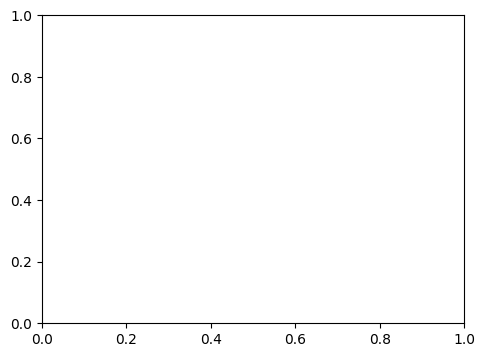

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], marker="o", label="Training")
plt.plot(history["val_loss"], marker="o", label="Validation")
plt.title("SpillNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history["train_dice"], marker="o", label="Training")
plt.plot(history["val_dice"], marker="o", label="Validation")
plt.title("SpillNet Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
model.load_state_dict(
    torch.load(
        f"{SAVE_DIR}/spillnet_unet_best.pth",
        map_location=device
    )
)

model.eval()

image_path, mask_path = random.choice(val_pairs)

image = Image.open(image_path).convert("L")
true_mask = Image.open(mask_path).convert("L")

input_image = TF.resize(image, (IMG_SIZE, IMG_SIZE))
input_tensor = (
    TF.to_tensor(input_image)
    .repeat(3, 1, 1)
    .unsqueeze(0)
    .to(device)
)

with torch.no_grad():
    logits = model(input_tensor)
    probability_map = torch.sigmoid(logits)[0, 0].cpu().numpy()
    predicted_mask = probability_map > 0.5

true_mask_resized = TF.resize(
    true_mask,
    (IMG_SIZE, IMG_SIZE),
    interpolation=InterpolationMode.NEAREST
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(input_image, cmap="gray")
plt.title("SAR Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(true_mask_resized, cmap="gray")
plt.title("Actual Spill Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted_mask, cmap="gray")
plt.title("SpillNet Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.eval()

foreground_dice_scores = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        predictions = (torch.sigmoid(model(images)) > 0.5).float()

        for prediction, mask in zip(predictions, masks):
            # Evaluate only images with at least one true spill pixel
            if mask.sum() > 0:
                intersection = (prediction * mask).sum()
                total = prediction.sum() + mask.sum()

                dice = (2 * intersection + 1e-7) / (total + 1e-7)
                foreground_dice_scores.append(dice.item())

print("Validation images containing a spill:", len(foreground_dice_scores))
print("Foreground-only mean Dice:", np.mean(foreground_dice_scores))
print("Foreground-only median Dice:", np.median(foreground_dice_scores))
print("Best image Dice:", np.max(foreground_dice_scores))
print("Worst image Dice:", np.min(foreground_dice_scores))

In [ ]:
model.eval()
results = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        predicted_masks = (torch.sigmoid(model(images)) > 0.5).float()

        for image, mask, prediction in zip(images, masks, predicted_masks):
            if mask.sum() > 0:
                intersection = (prediction * mask).sum()
                total = prediction.sum() + mask.sum()
                dice = ((2 * intersection + 1e-7) / (total + 1e-7)).item()

                results.append((
                    dice,
                    image.cpu(),
                    mask.cpu(),
                    prediction.cpu()
                ))

median_dice = np.median([result[0] for result in results])

representative = min(
    results,
    key=lambda result: abs(result[0] - median_dice)
)

dice, image, actual_mask, predicted_mask = representative

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image[0], cmap="gray")
plt.title("SAR Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(actual_mask[0], cmap="gray")
plt.title("Actual Spill Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted_mask[0], cmap="gray")
plt.title(f"SpillNet Prediction\nDice: {dice:.3f}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    image = Image.open(filename).convert("L")
    resized_image = TF.resize(image, (IMG_SIZE, IMG_SIZE))

    input_tensor = (
        TF.to_tensor(resized_image)
        .repeat(3, 1, 1)
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():
        probability_map = torch.sigmoid(model(input_tensor))[0, 0].cpu().numpy()

    predicted_mask = probability_map > 0.5
    spill_area_percent = predicted_mask.mean() * 100

    if spill_area_percent > 0.1:
        result = "OIL SPILL DETECTED"
        confidence = probability_map[predicted_mask].mean() * 100
    else:
        result = "NO OIL SPILL DETECTED"
        confidence = (1 - probability_map).mean() * 100

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(resized_image, cmap="gray")
    plt.title("Uploaded SAR Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_mask, cmap="gray")
    plt.title(
        f"SpillNet Result: {result}\n"
        f"Estimated confidence: {confidence:.1f}%\n"
        f"Predicted spill area: {spill_area_percent:.2f}%"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Convert True/False predicted mask to a binary OpenCV image
binary_mask = (predicted_mask.astype(np.uint8) * 255)

# Find separate detected spill regions
contours, _ = cv2.findContours(
    binary_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

MIN_COMPONENT_AREA = 100  # removes tiny noise regions
geometry_features = []

for index, contour in enumerate(contours, start=1):
    area = cv2.contourArea(contour)

    if area < MIN_COMPONENT_AREA:
        continue

    perimeter = cv2.arcLength(contour, True)
    x, y, width, height = cv2.boundingRect(contour)

    moments = cv2.moments(contour)
    centroid_x = moments["m10"] / moments["m00"]
    centroid_y = moments["m01"] / moments["m00"]

    compactness = (
        (4 * np.pi * area) / (perimeter ** 2)
        if perimeter > 0 else 0
    )

    # Ellipse geometry requires at least 5 contour points
    if len(contour) >= 5:
        (_, _), (axis_1, axis_2), angle = cv2.fitEllipse(contour)

        major_axis = max(axis_1, axis_2)
        minor_axis = min(axis_1, axis_2)
        orientation_degrees = angle
    else:
        major_axis = np.nan
        minor_axis = np.nan
        orientation_degrees = np.nan

    geometry_features.append({
        "spill_patch": index,
        "area_pixels": round(area, 2),
        "area_percent": round((area / predicted_mask.size) * 100, 2),
        "perimeter_pixels": round(perimeter, 2),
        "centroid_x": round(centroid_x, 1),
        "centroid_y": round(centroid_y, 1),
        "bbox_width_pixels": width,
        "bbox_height_pixels": height,
        "major_axis_pixels": round(major_axis, 2),
        "minor_axis_pixels": round(minor_axis, 2),
        "orientation_degrees": round(orientation_degrees, 2),
        "compactness": round(compactness, 3)
    })

geometry_df = pd.DataFrame(geometry_features)

print("Detected spill patches:", len(geometry_df))
print("Total predicted spill area: "
      f"{predicted_mask.mean() * 100:.2f}%")

display(geometry_df)

In [ ]:
overlay = cv2.cvtColor(
    np.array(resized_image),
    cv2.COLOR_GRAY2RGB
)

for row in geometry_features:
    x = int(row["centroid_x"])
    y = int(row["centroid_y"])

# Draw contours and patch labels
valid_contours = [
    contour for contour in contours
    if cv2.contourArea(contour) >= MIN_COMPONENT_AREA
]

cv2.drawContours(overlay, valid_contours, -1, (0, 255, 0), 2)

for index, contour in enumerate(valid_contours, start=1):
    x, y, width, height = cv2.boundingRect(contour)

    cv2.rectangle(
        overlay, (x, y), (x + width, y + height),
        (255, 0, 0), 1
    )

    cv2.putText(
        overlay, f"Patch {index}", (x, max(y - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1
    )

plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.title("SpillNet Geometry: Contours and Spill Patches")
plt.axis("off")
plt.show()

NameError: name 'resized_image' is not defined

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files
from IPython.display import display
import torchvision.transforms.functional as TF

# Settings
MASK_THRESHOLD = 0.5
MIN_COMPONENT_AREA = 100  # ignore tiny predicted regions/noise

model.eval()

# Upload one SAR image manually
uploaded = files.upload()

for filename in uploaded.keys():

    # 1. Prepare image for SpillNet
    original_image = Image.open(filename).convert("L")
    resized_image = TF.resize(original_image, (IMG_SIZE, IMG_SIZE))

    input_tensor = (
        TF.to_tensor(resized_image)
        .repeat(3, 1, 1)
        .unsqueeze(0)
        .to(device)
    )

    # 2. Predict oil-spill mask
    with torch.no_grad():
        probability_map = torch.sigmoid(
            model(input_tensor)
        )[0, 0].cpu().numpy()

    raw_mask = probability_map > MASK_THRESHOLD
    binary_mask = (raw_mask.astype(np.uint8) * 255)

    # 3. Find and filter separate spill patches
    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    valid_contours = [
        contour for contour in contours
        if cv2.contourArea(contour) >= MIN_COMPONENT_AREA
    ]

    # Create final mask containing only valid spill patches
    final_mask = np.zeros_like(binary_mask)

    if valid_contours:
        cv2.drawContours(
            final_mask,
            valid_contours,
            -1,
            255,
            thickness=cv2.FILLED
        )

    final_mask_bool = final_mask > 0
    spill_area_percent = final_mask_bool.mean() * 100

    # 4. Oil-spill decision and estimated confidence
    if len(valid_contours) > 0:
        result = "OIL SPILL DETECTED"
        confidence = probability_map[final_mask_bool].mean() * 100
    else:
        result = "NO OIL SPILL DETECTED"
        confidence = (1 - probability_map).mean() * 100

    # 5. Extract geometry for every valid spill patch
    geometry_features = []

    for patch_number, contour in enumerate(valid_contours, start=1):
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)

        x, y, width, height = cv2.boundingRect(contour)

        moments = cv2.moments(contour)
        centroid_x = moments["m10"] / moments["m00"]
        centroid_y = moments["m01"] / moments["m00"]

        compactness = (
            (4 * np.pi * area) / (perimeter ** 2)
            if perimeter > 0 else 0
        )

        if len(contour) >= 5:
            (_, _), (axis_1, axis_2), angle = cv2.fitEllipse(contour)

            major_axis = max(axis_1, axis_2)
            minor_axis = min(axis_1, axis_2)
            orientation_degrees = angle
        else:
            major_axis = np.nan
            minor_axis = np.nan
            orientation_degrees = np.nan

        geometry_features.append({
            "spill_patch": patch_number,
            "area_pixels": round(area, 2),
            "area_percent": round(
                (area / final_mask_bool.size) * 100, 2
            ),
            "perimeter_pixels": round(perimeter, 2),
            "centroid_x": round(centroid_x, 1),
            "centroid_y": round(centroid_y, 1),
            "bbox_width_pixels": width,
            "bbox_height_pixels": height,
            "major_axis_pixels": round(major_axis, 2),
            "minor_axis_pixels": round(minor_axis, 2),
            "orientation_degrees": round(orientation_degrees, 2),
            "compactness": round(compactness, 3)
        })

    geometry_df = pd.DataFrame(geometry_features)

    # 6. Create contour + bounding-box overlay
    overlay = cv2.cvtColor(
        np.array(resized_image),
        cv2.COLOR_GRAY2RGB
    )

    cv2.drawContours(
        overlay,
        valid_contours,
        -1,
        (0, 255, 0),  # green contour
        2
    )

    for patch_number, contour in enumerate(valid_contours, start=1):
        x, y, width, height = cv2.boundingRect(contour)

        cv2.rectangle(
            overlay,
            (x, y),
            (x + width, y + height),
            (255, 0, 0),  # red bounding box
            1
        )

        cv2.putText(
            overlay,
            f"Patch {patch_number}",
            (x, max(y - 6, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1,
            cv2.LINE_AA
        )

    # 7. Display detection result and mask
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(resized_image, cmap="gray")
    plt.title("Uploaded SAR Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(final_mask_bool, cmap="gray")
    plt.title(
        f"SpillNet: {result}\n"
        f"Estimated confidence: {confidence:.1f}%\n"
        f"Predicted spill area: {spill_area_percent:.2f}%"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # 8. Display geometry overlay
    plt.figure(figsize=(8, 8))
    plt.imshow(overlay)
    plt.title("SpillNet Geometry: Contours and Spill Patches")
    plt.axis("off")
    plt.show()

    # 9. Display geometry measurements
    print("Detected spill patches:", len(valid_contours))
    print(f"Total predicted spill area: {spill_area_percent:.2f}%")

    if not geometry_df.empty:
        display(geometry_df)
    else:
        print("No spill patch larger than the noise threshold was detected.")

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

!pip -q install segmentation-models-pytorch

import torch
import segmentation_models_pytorch as smp

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMG_SIZE = 256

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,   # weights are loaded from your saved SpillNet model
    in_channels=3,
    classes=1
)

MODEL_PATH = "/content/drive/MyDrive/SpillNet/spillnet_unet_best.pth"

model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)

model = model.to(device)
model.eval()

print("SpillNet restored successfully on:", device)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 1.9 MB/s eta 0:00:00
SpillNet restored successfully on: cuda
